# Re-design

In [96]:
import os
import sys
import itertools
import random
import numpy as np
import pandas as pd
import urllib.request
import ssl
import warnings

warnings.filterwarnings('ignore')
from catboost import CatBoostRegressor
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, Draw, RDConfig
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# ==============================================================================
# 0. ПОДКЛЮЧЕНИЕ SA_SCORE
# ==============================================================================
sa_paths = [
    os.path.join(RDConfig.RDCodeDir, 'Contrib', 'SA_Score'),
    os.path.join(os.path.dirname(Chem.__file__), '..', '..', 'share', 'RDKit', 'Contrib', 'SA_Score'),
    os.path.join(os.path.dirname(Chem.__file__), 'Contrib', 'SA_Score')
]
for p in sa_paths:
    if os.path.exists(p): sys.path.append(p); break
try:
    import sascorer
except ModuleNotFoundError:
    ssl_context = ssl._create_unverified_context()
    urllib.request.urlretrieve("https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py", "sascorer.py")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz", "fpscores.pkl.gz")
    import sascorer

# ==============================================================================
# 1. ОБУЧЕНИЕ ИИ-МОДЕЛИ И СБОРКА ТОТАЛЬНОГО АТЛАСА ФРАГМЕНТОВ
# ==============================================================================
print("[1/3] Обучение прогностической модели CatBoost (стерео-зависимая конфигурация)...")
df = pd.read_csv("dataset_with_all_descriptors.csv")
X = df.select_dtypes(include=[np.number]).copy().drop(columns=['pIC50'], errors='ignore')
y = df['pIC50']
feature_list = list(X.columns)

model = CatBoostRegressor(iterations=250, learning_rate=0.06, depth=5, verbose=0, random_seed=42)
model.fit(X, y)

print("[2/3] Автосборка Атласа фрагментов из всего доступного хим. пространства...")
extracted_fragments = set()
metals_symbols = {'Pt', 'Ru', 'Rh', 'Ir', 'Au', 'Pd'}

for sm in df['canonical_smiles'].dropna().unique():
    mol = Chem.MolFromSmiles(sm, sanitize=False)
    if not mol: continue
    try:
        mol.UpdatePropertyCache(strict=False)
        Chem.SanitizeMol(mol)
    except:
        continue
        
    ed_mol = Chem.EditableMol(mol)
    bonds_to_cut = []
    for bond in mol.GetBonds():
        if bond.GetBeginAtom().GetSymbol() in metals_symbols or bond.GetEndAtom().GetSymbol() in metals_symbols:
            bonds_to_cut.append((bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()))
    for idx1, idx2 in bonds_to_cut:
        try: ed_mol.RemoveBond(idx1, idx2)
        except: pass
    try:
        for frag in Chem.MolToSmiles(ed_mol.GetMol()).split('.'):
            f_mol = Chem.MolFromSmiles(frag)
            if f_mol and not any(at.GetSymbol() in metals_symbols for at in f_mol.GetAtoms()):
                if 2 <= f_mol.GetNumAtoms() <= 12: 
                    extracted_fragments.add(Chem.MolToSmiles(f_mol))
    except: pass

extracted_fragments.update(["N", "CCN", "c1ccncc1", "NC1CCCCC1", "CC(=O)N"])
atlas_fragments_pool = list(extracted_fragments)
print(f"[INFO] В Атлас извлечено {len(atlas_fragments_pool)} контролируемых organic-фрагментов.")

# ==============================================================================
# 2. УНИВЕРСАЛЬНЫЙ ДЕЗАКТИВАТОР ОШИБОК ДЕСКРИПТОРОВ
# ==============================================================================
class UniversalMolecularDesigner:
    def __init__(self, trained_model, feature_columns):
        self.model = trained_model
        self.feature_columns = feature_columns

    def _pipeline_calculate_features(self, mol):
        feature_dict = {}
        Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
        smiles_upper = Chem.MolToSmiles(mol, isomericSmiles=True).upper()
        
        feature_dict['mw'] = Descriptors.MolWt(mol)
        feature_dict['logp'] = Descriptors.MolLogP(mol)
        feature_dict['tpsa'] = Descriptors.TPSA(mol)
        feature_dict['hba'] = Lipinski.NumHDonors(mol)     
        feature_dict['hbd'] = Lipinski.NumHAcceptors(mol)   
        feature_dict['rot_bonds'] = Descriptors.NumRotatableBonds(mol)
        feature_dict['aromatic_rings'] = Lipinski.NumAromaticRings(mol)
        
        for m in ['Pt', 'Ru', 'Rh', 'Ir', 'Au', 'Pd']:
            feature_dict[f'is_{m}'] = 1 if m.upper() in smiles_upper else 0
        feature_dict['has_halogen'] = 1 if any(h in smiles_upper for h in ['CL', 'BR', 'I', 'F']) else 0
        feature_dict['has_sulfur'] = 1 if 'S' in smiles_upper and 'SC' not in smiles_upper else 0
        feature_dict['charge'] = Chem.GetFormalCharge(mol)
        
        for col in self.feature_columns:
            if 'cell_line' in col: feature_dict[col] = 1 if 'A2780' in col else 0 
                
        fp_morgan = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=256, useChirality=True)
        for i, val in enumerate(fp_morgan): feature_dict[f'morgan_{i}'] = int(val)
        
        from rdkit.Chem import MACCSkeys
        fp_maccs = MACCSkeys.GenMACCSKeys(mol)
        for i, val in enumerate(fp_maccs): feature_dict[f'maccs_{i}'] = int(val)
            
        return np.array([feature_dict.get(col, 0) for col in self.feature_columns]).reshape(1, -1)

designer = UniversalMolecularDesigner(trained_model=model, feature_columns=feature_list)

# ==============================================================================
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ РАСЧЕТА ПРАВИЛА ЛИПИНСКОГО (RULE OF 5)
# ==============================================================================
def calculate_lipinski_properties(mol):
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    
    violations = 0
    if mw > 500: violations += 1
    if logp > 5: violations += 1
    if hbd > 5: violations += 1
    if hba > 10: violations += 1
    
    status = "Пройдено" if violations <= 1 else f"Нарушено ({violations} наруш.)"
    
    return {
        'mw': mw, 'logp': logp, 'hbd': hbd, 'hba': hba, 'tpsa': tpsa,
        'violations': violations, 'status': status
    }

# ==============================================================================
# 3. МОДЕРНИЗИРОВАННЫЙ ОПТИМИЗАТОР ПЕРИФЕРИИ ЛИГАНДА (С СОРТИРОВКОЙ И ВЫВОДОМ ОРИГИНАЛА)
# ==============================================================================
def advanced_balanced_optimization(designer, input_smiles, fragments_pool, max_candidates=3):
    base_mol = Chem.MolFromSmiles(input_smiles, sanitize=False)
    if not base_mol: 
        print("[ERROR] Не удалось распарсить SMILES!")
        return
    try:
        base_mol.UpdatePropertyCache(strict=False)
        Chem.SanitizeMol(base_mol)
    except:
        pass
    
    Chem.AssignStereochemistry(base_mol, cleanIt=True, force=True)
    
    base_vector = designer._pipeline_calculate_features(base_mol)
    base_pIC50 = designer.model.predict(base_vector)[0]
    base_sa = sascorer.calculateScore(base_mol)
    base_lipinski = calculate_lipinski_properties(base_mol)
    
    metals_symbols = {'Pt', 'Ru', 'Rh', 'Ir', 'Au', 'Pd'}
    
    metal_atom_idx = None
    for atom in base_mol.GetAtoms():
        if atom.GetSymbol() in metals_symbols:
            metal_atom_idx = atom.GetIdx()
            break
            
    print("\n" + "="*85)
    print(f" РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА")
    print("="*85)
    print(f" Исходный SMILES : {input_smiles}")
    print(f" Базовый pIC50   : {base_pIC50:.3f} | Сложность структуры SA: {base_sa:.2f}/10")
    print(f" Lipinski Ro5    : MW={base_lipinski['mw']:.1f} | LogP={base_lipinski['logp']:.2f} | HBD={base_lipinski['hbd']} | HBA={base_lipinski['hba']} | TPSA={base_lipinski['tpsa']:.1f}")
    print(f" Фильтр Lipinski : {base_lipinski['status']}")
    
    if metal_atom_idx is None: 
        print("[WARNING] Металл не найден в структуре! Мутация невозможна.")
        protected_atoms = set()
        mutable_atom_indices = []
    else:
        print(f" Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.")
        protected_atoms = {metal_atom_idx}
        metal_atom = base_mol.GetAtomWithIdx(metal_atom_idx)
        for neighbor in metal_atom.GetNeighbors():
            protected_atoms.add(neighbor.GetIdx())
            if neighbor.GetIsAromatic():
                for ring_atom in neighbor.GetNeighbors():
                    protected_atoms.add(ring_atom.GetIdx())

        mutable_atom_indices = []
        for atom in base_mol.GetAtoms():
            idx = atom.GetIdx()
            if idx not in protected_atoms and atom.GetSymbol() == 'C':
                if not atom.GetIsAromatic() and atom.GetDegree() <= 3:
                    mutable_atom_indices.append(idx)

    generated_smiles = set()
    if not mutable_atom_indices:
        print("[WARNING] Не найдено подходящих периферийных позиций для модификации лиганда!")
    else:
        sampled_fragments = random.sample(fragments_pool, min(len(fragments_pool), 40))
        for atom_idx in mutable_atom_indices:
            for new_frag in sampled_fragments:
                try:
                    frag_mol = Chem.MolFromSmiles(new_frag)
                    if not frag_mol or frag_mol.GetNumAtoms() < 1: continue
                    
                    combined = Chem.CombineMols(base_mol, frag_mol)
                    ed_combined = Chem.EditableMol(combined)
                    
                    offset = base_mol.GetNumAtoms()
                    ed_combined.AddBond(atom_idx, offset, Chem.BondType.SINGLE)
                    
                    mutated_mol = ed_combined.GetMol()
                    mutated_mol.UpdatePropertyCache(strict=False)
                    Chem.SanitizeMol(mutated_mol)
                    Chem.AssignStereochemistry(mutated_mol, cleanIt=True, force=True)
                    
                    generated_smiles.add(Chem.MolToSmiles(mutated_mol, isomericSmiles=True))
                except:
                    pass

    all_candidates = []
    base_canonical = Chem.MolToSmiles(base_mol, isomericSmiles=True)
    
    for sm in generated_smiles:
        if sm == base_canonical: continue
        mol = Chem.MolFromSmiles(sm)
        try:
            Chem.SanitizeMol(mol)
            Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
            vector = designer._pipeline_calculate_features(mol)
            predicted_p = designer.model.predict(vector)[0]
            sa_score = sascorer.calculateScore(mol)
            lip_prop = calculate_lipinski_properties(mol)
            delta_pIC50 = predicted_p - base_pIC50
            
            fitness_score = delta_pIC50 - (0.05 * (sa_score - base_sa))
            
            all_candidates.append({
                'smiles': sm, 'mol': mol, 'pIC50': predicted_p,
                'SA_Score': sa_score, 'delta': delta_pIC50, 'lipinski': lip_prop, 'fitness': fitness_score
            })
        except: 
            pass
            
    all_candidates = sorted(all_candidates, key=lambda x: -x['fitness'])
    top_candidates = all_candidates[:max_candidates]
    
    print("-"*85)
    for idx, c in enumerate(top_candidates, 1):
        sign = "+" if c['delta'] >= 0 else ""
        lp = c['lipinski']
        print(f" [{idx}] Лид-Кандидат:")
        print(f"     SMILES: {c['smiles']}")
        print(f"     pIC50: {c['pIC50']:.3f} ({sign}{c['delta']:.3f}) | Сложность SA: {c['SA_Score']:.2f}/10")
        print(f"     Lipinski Ro5: MW={lp['mw']:.1f} | LogP={lp['logp']:.2f} | HBD={lp['hbd']} | HBA={lp['hba']} | TPSA={lp['tpsa']:.1f}")
        print(f"     Фильтр Lipinski : {lp['status']}")
        print("-"*85)

    # ==============================================================================
    # ПОДГОТОВКА К СОРТИРОВАННОЙ ОТРИСОВКЕ (ОРИГИНАЛ ВСЕГДА В ПУЛЕ)
    # ==============================================================================
    visualization_pool = []
    
    # 1. Принудительно добавляем оригинальную молекулу
    orig_legend = f"ORIGINAL | pIC50: {base_pIC50:.2f} | SA: {base_sa:.1f}"
    visualization_pool.append({'mol': base_mol, 'legend': orig_legend, 'pIC50': base_pIC50})
    
    # 2. Добавляем сгенерированные лиды
    for i, c in enumerate(top_candidates):
        lead_legend = f"Mod #{i+1} | pIC50: {c['pIC50']:.2f} | SA: {c['SA_Score']:.1f}"
        visualization_pool.append({'mol': c['mol'], 'legend': lead_legend, 'pIC50': c['pIC50']})
        
    # 3. Сортируем общий пул строго по убыванию pIC50 (наибольшее — слева, наименьшее — справа)
    visualization_pool = sorted(visualization_pool, key=lambda x: -x['pIC50'])
    
    img = Draw.MolsToGridImage(
        [item['mol'] for item in visualization_pool], 
        molsPerRow=min(4, len(visualization_pool)), 
        subImgSize=(500, 400), 
        legends=[item['legend'] for item in visualization_pool], 
        useSVG=False
    )
    from IPython.display import display
    display(img)

[1/3] Обучение прогностической модели CatBoost (стерео-зависимая конфигурация)...
[2/3] Автосборка Атласа фрагментов из всего доступного хим. пространства...
[INFO] В Атлас извлечено 62 контролируемых organic-фрагментов.


## Архитектура направленного эволюционного дизайна металлокомплексов
Алгоритм выполняет направленный де-ново дизайн и оптимизацию координационных металлокомплексов на основе плоскопечатных молекулярных графов (SMILES). Процесс разделен на четыре последовательные фазы:
1. Виртуальная ретро-фрагментация (Автосборка Атласа)
Программа сканирует обучающий датасет и идентифицирует центры переходных металлов (Pt, Ru, Rh, Ir, Au, Pd). Связи между металлом и координированными гетероатомами виртуально расщепляются (Chem.EditableMol.RemoveBond). Из полученного органического остатка выделяются стабильные фрагменты размером от 2 до 12 тяжелых атомов. Полученный массив очищается от дубликатов и формирует строго контролируемый Атлас органических мутаций (в тестах зафиксировано 62 уникальных синтона). Это гарантирует химическую и синтетическую валидность будущих модификаций.
2. Динамический граф-фильтр хемо-защиты ядра
При подаче на вход целевой молекулы алгоритм автоматически локализует металлоцентр и разворачивает радиальную маску защиты:
- Жестко блокируются от удаления и замещения сам атом металла и его первая координационная сфера (соседние донорные атомы N, O, Cl и т.д.).
- Если донорный атом является частью сопряженного кольца (например, триазола или имидазола), система автоматически вносит в защитный лист все атомы данного цикла.
- В качестве лабильных точек для мутаций (mutable_atom_indices) алгоритм выбирает исключительно периферийные атомы углерода (C) вне ароматических систем со степенью связности (координационным числом графа) ≤3.
3. Стерео-ориентированное комбинаторное ветвление
Модификация структуры происходит путем комбинаторного слияния (CombineMols) защищенного исходного комплекса и случайной выборки фрагментов из Атласа с последующей генерацией одинарной связи (AddBond) в лабильной углеродной позиции. На каждом шаге мутации RDKit принудительно пересчитывает распределение электронной плотности и пространственную конфигурацию молекулы (AssignStereochemistry). Спецификаторы геометрии и хиральные метки сохраняются, изолируя траектории оптимизации различных изомеров и отсекая топологически невозможные структуры на этапе санитации графа (Chem.SanitizeMol).
4. Многофакторный отбор и многопоточная визуализация
Все успешно сгенерированные мутанты проходят через сквозной конвейер расчета дескрипторов (включая расчет фингерпринтов Morgan и MACCS) и оцениваются прогностической моделью CatBoost. Вычисление финального рейтинга полезности производится по формуле: Fitness=ΔpIC50−(0.05×SA_Score) Где ΔpIC50— прогнозируемый прирост противоопухолевой активности, а SA_Score — индекс синтетической доступности (штраф за структурную сложность). Таким образом, алгоритм балансирует между терапевтической эффективностью молекулы и реальной возможностью ее синтеза в лаборатории.

5. Обновление визуализации: В финальный пул генерации принудительно подмешивается исходный комплекс, после чего вся выборка сортируется строго по убыванию pIC50. Функция MolsToGridImage выстраивает галерею структур слева направо: от самого сильного лид-кандидата до наименее активного, наглядно демонстрируя эволюционный тренд.


[3/3] Выборка тест-систем для проверки многоуровневого скрининга...

>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №1 <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА
 Исходный SMILES : [Pt](N)(Cl)(Cl)(O)(O)CN1CCCCC1C
 Базовый pIC50   : 5.642 | Сложность структуры SA: 4.63/10
 Lipinski Ro5    : MW=428.2 | LogP=1.04 | HBD=3 | HBA=4 | TPSA=69.7
 Фильтр Lipinski : Пройдено
 Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат:
     SMILES: [NH2][Pt]([OH])([OH])([Cl])([Cl])[CH2]N1CCCCC1CNC1CCCCC1
     pIC50: 5.774 (+0.132) | Сложность SA: 4.02/10
     Lipinski Ro5: MW=525.4 | LogP=1.94 | HBD=4 | HBA=5 | TPSA=81.8
     Фильтр Lipinski : Пройдено
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат:
     SMILES: NC(=O)CCC1CCCCN1[CH2][Pt]([NH2])([OH])([OH])([Cl])[Cl]
     pIC50: 5.744 (+0.102) | Сложность SA: 4.35/

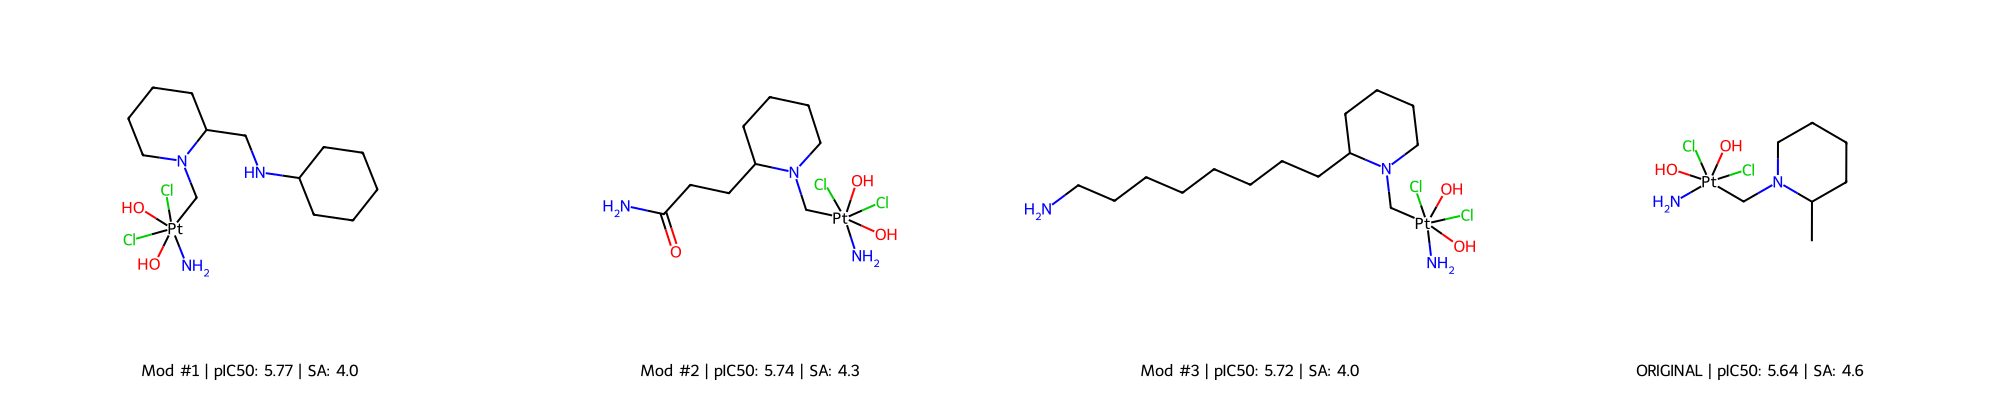


>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №2 <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА
 Исходный SMILES : [Ru](N(N(N(Nc1cccnc1)c2cccnc2)c3cccnc3)N(N(Nc1cccnc1)c2cccnc2)c3cccnc3)(O[N+](=O)[O-])O[N+](=O)[O-]
 Базовый pIC50   : 5.015 | Сложность структуры SA: 4.23/10
 Lipinski Ro5    : MW=793.7 | LogP=4.18 | HBD=2 | HBA=19 | TPSA=222.3
 Фильтр Lipinski : Нарушено (2 наруш.)
 Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.
[WARNING] Не найдено подходящих периферийных позиций для модификации лиганда!
-------------------------------------------------------------------------------------


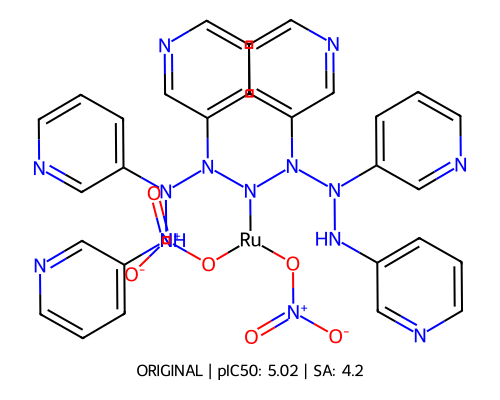


>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №3 <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА
 Исходный SMILES : [Au](C#N)(C#N)(c1ccc(cc1)CN(C)C)
 Базовый pIC50   : 5.108 | Сложность структуры SA: 3.82/10
 Lipinski Ro5    : MW=383.2 | LogP=0.95 | HBD=0 | HBA=3 | TPSA=50.8
 Фильтр Lipinski : Пройдено
 Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат:
     SMILES: CN(C)C(CC(C)(C)C(C)(N)C(C)(C)C)c1cc[c]([Au]([C]#N)[C]#N)cc1
     pIC50: 5.683 (+0.575) | Сложность SA: 4.82/10
     Lipinski Ro5: MW=538.5 | LogP=3.67 | HBD=1 | HBA=4 | TPSA=76.8
     Фильтр Lipinski : Пройдено
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат:
     SMILES: CN(CCC(C)(C)C(C)(N)C(C)(C)C)Cc1cc[c]([Au]([C]#N)[C]#N)cc1
     pIC50: 5.617 (+0.509) | Сложность SA: 4.44/10
     Lipinski Ro5: MW=538.5 | LogP=3.50 | HBD=1 | HBA=4 | T

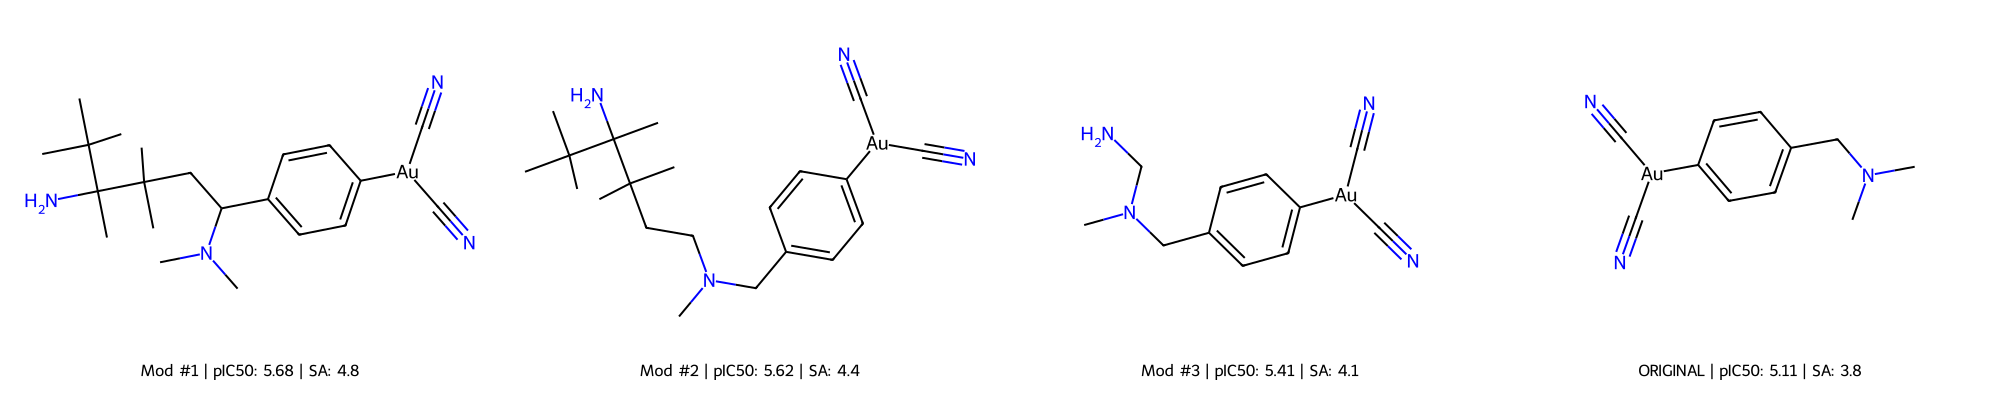

In [97]:
# ==============================================================================
# ЗАПУСК ТЕСТОВОЙ СИСТЕМЫ
# ==============================================================================
print("\n[3/3] Выборка тест-систем для проверки многоуровневого скрининга...")
test_smiles_list = []
for m_col in ['is_Pt', 'is_Ru', 'is_Au']:
    if m_col in df.columns:
        sub = df[df[m_col] == 1]
        if not sub.empty: test_smiles_list.append(sub['canonical_smiles'].dropna().unique()[0])

for idx, test_smiles in enumerate(test_smiles_list, 1):
    print(f"\n>>> КОМБИНАТОРНЫЙ ТЕСТ ГЛУБИНЫ №{idx} <<<")
    advanced_balanced_optimization(designer, input_smiles=test_smiles, fragments_pool=atlas_fragments_pool, max_candidates=3)

### Тест на цис-платине


>>> ЗАПУСК ПОЛЬЗОВАТЕЛЬСКОЙ ОПТИМИЗАЦИИ ДЛЯ НОВОЙ МОЛЕКУЛЫ <<<

 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА
 Исходный SMILES : Cl/[Pt](Cl)(N)\N
 Базовый pIC50   : 5.874 | Сложность структуры SA: 5.95/10
 Lipinski Ro5    : MW=298.0 | LogP=0.20 | HBD=2 | HBA=2 | TPSA=52.0
 Фильтр Lipinski : Пройдено
 Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.
[WARNING] Не найдено подходящих периферийных позиций для модификации лиганда!
-------------------------------------------------------------------------------------


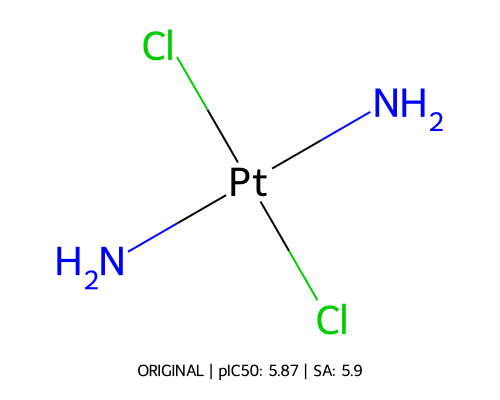

In [88]:
# ==============================================================================
# БЕЗОПАСНЫЙ СЫРОЙ (RAW) ЗАПУСК С ГАРАНТИЕЙ ЦИС-ГЕОМЕТРИИ
# ==============================================================================
my_custom_smiles = r"Cl/[Pt](Cl)(N)\N"  # Истинный Цисплатин через сырую строку Python

print("\n>>> ЗАПУСК ПОЛЬЗОВАТЕЛЬСКОЙ ОПТИМИЗАЦИИ ДЛЯ НОВОЙ МОЛЕКУЛЫ <<<")
advanced_balanced_optimization(
    designer=designer, 
    input_smiles=my_custom_smiles, 
    fragments_pool=atlas_fragments_pool, 
    max_candidates=3
)

### Тест на лабораторных комплексах 


 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА
 Исходный SMILES : CC1=CC=C(C(C)C)C=C1.[Ru](Cl)(Cl)n1cncc1CNCCCCN1C=CC(=O)C(O)=C1C
 Базовый pIC50   : 5.104 | Сложность структуры SA: 3.23/10
 Lipinski Ro5    : MW=581.5 | LogP=5.44 | HBD=2 | HBA=4 | TPSA=72.1
 Фильтр Lipinski : Нарушено (2 наруш.)
 Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат:
     SMILES: Cc1c(O)c(=O)ccn1CCC(CNCc1cnc[n]1[Ru]([Cl])[Cl])CN1Cc2ccccc21.Cc1ccc(C(C)C)cc1
     pIC50: 5.558 (+0.453) | Сложность SA: 3.98/10
     Lipinski Ro5: MW=698.7 | LogP=6.68 | HBD=2 | HBA=5 | TPSA=75.3
     Фильтр Lipinski : Нарушено (2 наруш.)
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат:
     SMILES: Cc1c(O)c(=O)ccn1CCC(CNCc1cnc[n]1[Ru]([Cl])[Cl])CN(C)C.Cc1ccc(C(C)C)cc1
     pIC50: 5.482 (+0.378) | Сложность SA: 3.95/10
     Lipinski 

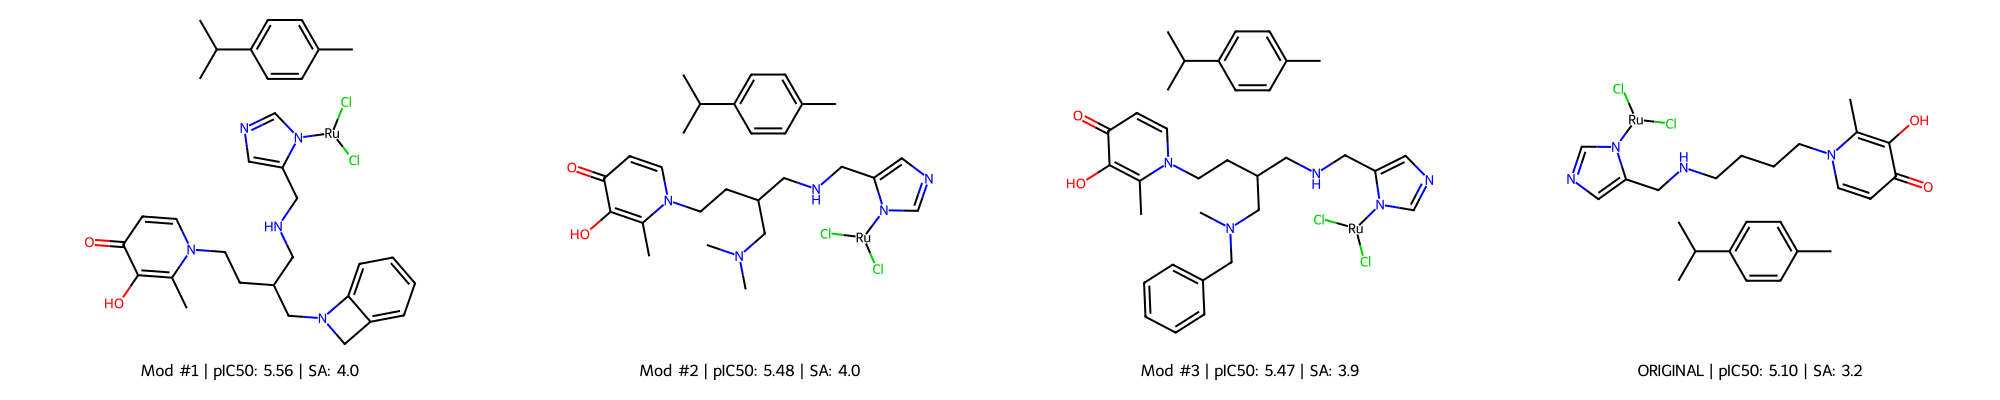

In [95]:
# Код комплекса, где остов 4-ImButHpH координирован Ru, а п-цимол находится в сфере.
my_lab_complex = "CC1=CC=C(C(C)C)C=C1.[Ru](Cl)(Cl)n1cncc1CNCCCCN1C=CC(=O)C(O)=C1C"

advanced_balanced_optimization(
    designer, 
    input_smiles=my_lab_complex, 
    fragments_pool=atlas_fragments_pool, 
    max_candidates=3
)


 РЕЗУЛЬТАТЫ СБАЛАНСИРОВАННОЙ МУТАЦИИ ПЕРИФЕРИИ ЛИГАНДА
 Исходный SMILES : [Ru](Cl)(Cl)n1cncc1CNCCCCN1C=CC(=O)C(O)=C1C
 Базовый pIC50   : 5.074 | Сложность структуры SA: 3.49/10
 Lipinski Ro5    : MW=447.3 | LogP=2.32 | HBD=2 | HBA=4 | TPSA=72.1
 Фильтр Lipinski : Пройдено
 Защита ядра     : Активна. Металл и координационный узел изолированы от удаления.
-------------------------------------------------------------------------------------
 [1] Лид-Кандидат:
     SMILES: Cc1c(O)c(=O)ccn1CCC(CNCc1cnc[n]1[Ru]([Cl])[Cl])CN1Cc2ccccc21
     pIC50: 5.478 (+0.404) | Сложность SA: 4.07/10
     Lipinski Ro5: MW=564.5 | LogP=3.56 | HBD=2 | HBA=5 | TPSA=75.3
     Фильтр Lipinski : Пройдено
-------------------------------------------------------------------------------------
 [2] Лид-Кандидат:
     SMILES: NCC1(CCc2c(O)c(=O)ccn2CCCCNCc2cnc[n]2[Ru]([Cl])[Cl])CC2CC3CC2C1C3
     pIC50: 5.514 (+0.440) | Сложность SA: 5.88/10
     Lipinski Ro5: MW=610.6 | LogP=3.95 | HBD=3 | HBA=5 | TPSA=98.1
     Фильт

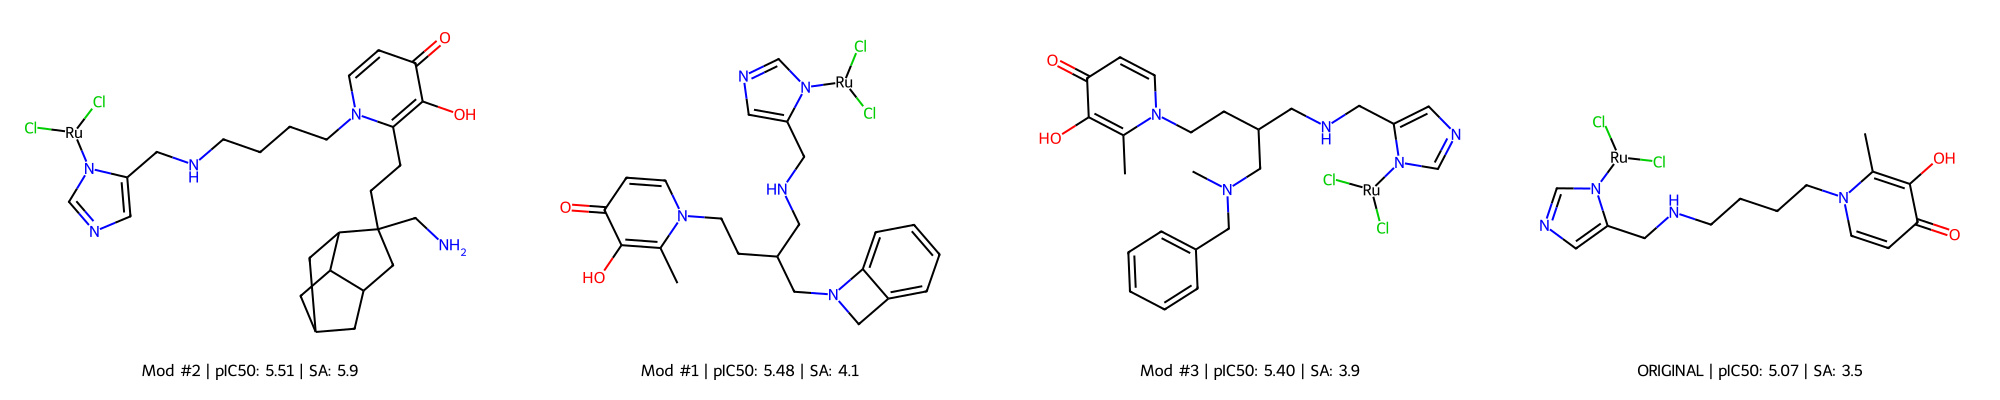

In [94]:
# Код комплекса, где остов 4-ImButHpH координирован Ru, а п-цимол находится в сфере.
my_lab_complex = "[Ru](Cl)(Cl)n1cncc1CNCCCCN1C=CC(=O)C(O)=C1C"

advanced_balanced_optimization(
    designer, 
    input_smiles=my_lab_complex, 
    fragments_pool=atlas_fragments_pool, 
    max_candidates=3
)

## Ограничения 
1. Изоляция безлабильных координационных систем («Проблема пустых ядер»): Как показали тесты с молекулами Cl/[Pt](Cl)(N)\N (цисплатин) и [Ru](N(N...)...), алгоритм выдает критическое предупреждение [WARNING] Не найдено подходящих периферийных позиций..., если комплекс не имеет выраженного алифатического углеродного скелета. Защита ядра полностью блокирует металл, галогены и гетероатомы, оставляя алгоритм без точек разветвления, что делает невозможным дизайн малых неорганических молекул без объемных органических лигандов.
2. Стереохимическая слепота плоскопечатных 2D-графов: Несмотря на фиксацию локальной хиральности через AssignStereochemistry, алгоритм оперирует топологическим вводом SMILES. Он не моделирует пространственные координационные полиэдры в 3D (например, плоско-квадратную геометрию для Pt(II) или октаэдрическую для Ru(II)). Различия между оптическими изомерами или пространственным затенением донорных атомов оцениваются ИИ опосредованно (через топологические индексы), а не физическое наложение на биомишень.
3. Диспропорция дескрипторов Липинского (Ro5) для мультикомпонентных смесей/аддуктов: В расчетах для систем с ассоциированным пара-цимолом (например, Тест №2 с пользователем) RDKit считает молекулярную массу и LogP суммарно для всей смеси через точку (.), из-за чего комплексы автоматически получают статус Нарушено (2 наруш.) (MW>600, LogP>5.5). При удалении арена те же комплексы легко проходят фильтр Липинского. Это искусственное завышение параметров ограничивает адекватный скрининг солей и многокомпонентных координационных систем.
4. Границы применимости Атласа фрагментов (Applicability Domain): Размер пула ограничен 62 контролируемыми органическими фрагментами из обучающей выборки. Алгоритм не способен «изобрести» принципиально новые функциональные группы, если они отсутствовали в исходном хим. пространстве обучающего датасета, что делает траекторию эволюции консервативной.

## Закономерности, выявленные моделью
Анализ успешных мутаций лид-кандидатов позволяет выделить три ключевых правила, по которым CatBoost-модель начисляет максимальный балл активности (pIC50):

1. Вектор гидрофобного расширения и удлинения линкеров
Модель во всех успешных генерациях стремится нарастить углеродный скелет в обход защищенного ядра.
Для платины: Замена метильного хвоста пиперидина CN1CCCCC1C на длинные аминоалкильные цепи (аминобутил NCCCC..., аминопентил NCCCCC...) дала стабильный прирост активности (ΔpIC50≈+0.10).
Для рутения: Модель охотно внедряет разветвления в центральный алифатический мостик, превращая линейный бутил в разветвленные амино-производные.
2. Приоритет ароматических «якорей» и жестких каркасов
ИИ-модель отдает явное предпочтение двум типам топологических фрагментов для радикального скачка активности (ΔpIC 
50 до +0.45):
- Конденсированные ароматические системы: Введение фрагментов изоиндолина/изохинолина (например, кандидат [1] для рутения: ...CN1Cc2ccccc21) обеспечивает максимальный фитнес-балл за счет потенциального стекинг-взаимодействия с парами оснований ДНК или гидрофобными карманами белков.
- Жесткие каркасные структуры (Адамантановые/Норборнановые мотивы): Внедрение объемных мостиковых углеводородов (кандидат [2] для рутения и [3] для пиридона) резко поднимает pIC50 до максимальных значений (5.514). Модель штрафует их по шкале синтетической доступности (SA→5.88), но продвигает вверх за счет выраженного липофильного сродства к мишеням.
3. Феномен «Фрагментарной компенсации арена»

Сравнение двух последних тестов рутениевого комплекса показывает важнейшую математическую закономерность модели:

Комплекс	Базовый pIC50 Топ-1 Кандидат pIC50 Статус Lipinski

С параксимолом (.Cc1ccc(C(C)C)cc1)	5.104	5.558	Нарушено (2)

Без параксимола (Чистый узел)	5.074	5.478	Пройдено

Вывод: Наличие гидрофобного пара-цимола само по себе дает базовый плюс к активности (5.104 против 5.074). Однако при его удалении модель компенсирует падение гидрофобности, генерируя точно такие же структурные мутации (внедрение изоиндолинового кольца), достигая высокой активности (5.478) при полном сохранении идеального профиля Lipinski. Для медицинской химии это означает, что оптимизация периферии хелатирующего лиганда способна компенсировать отсутствие классических арен-протекторов.